In [23]:
# ================
# Import packages
# ================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [15]:
df = pd.read_csv("data/heart_disease_uci.csv")

print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [16]:
df.shape

(920, 16)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [18]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [20]:
# Check missing data
df.isna().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [24]:
df["num"].value_counts().sort_index()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [25]:
# Create a binary target variable
df["heart_disease"] = (df["num"] > 0).astype(int)

df[["num", "heart_disease"]].head(10)

,num,heart_disease
0,0,0
1,2,1
2,1,1
3,0,0
4,0,0
5,0,0
6,3,1
7,0,0
8,2,1
9,1,1


In [26]:
df["heart_disease"].value_counts()

heart_disease
1    509
0    411
Name: count, dtype: int64

In [27]:
df["heart_disease"].value_counts(normalize=True)

heart_disease
1    0.553261
0    0.446739
Name: proportion, dtype: float64

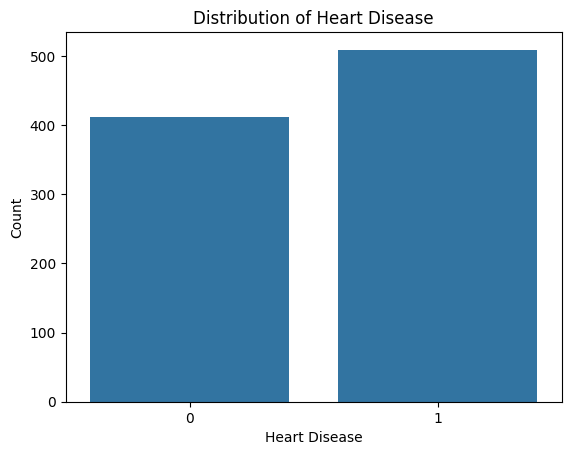

In [28]:
# Exploratory Data Analysis: target distribution
sns.countplot(data=df, x="heart_disease")
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

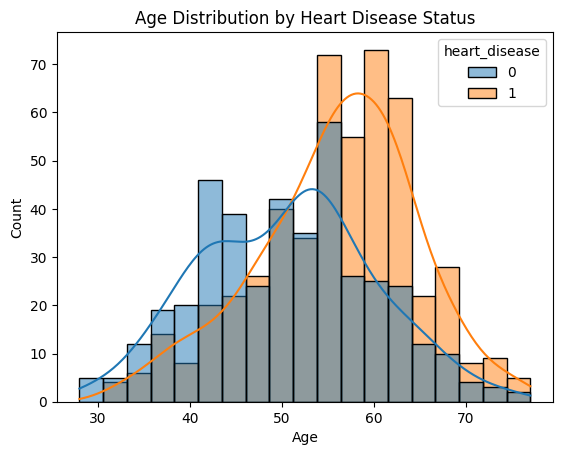

In [29]:
# EDA: age distribution
sns.histplot(data=df, x="age", hue="heart_disease", kde=True)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

**Observation**: The age distribution suggests that patients with heart disease tend to be older than patients without heart disease. The group without heart disease has many patients in their 40s and early 50s, while the heart disease group is more concentrated around the late 50s and early 60s. There is still overlap between the two groups, so age alone cannot perfectly separate patients with and without heart disease, but it appears to be a useful predictive feature.

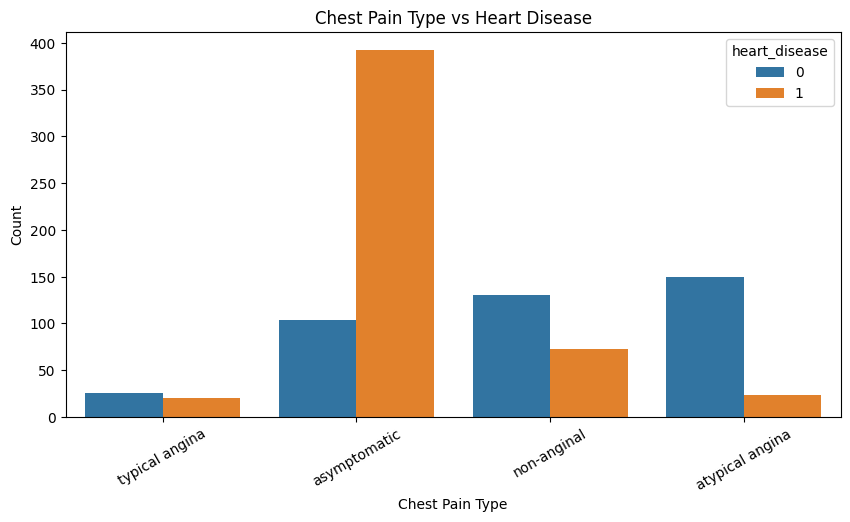

In [30]:
# EDA: chest pain type and heart disease
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="cp", hue="heart_disease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

**Observation**: The chest pain type variable appears to be strongly associated with heart disease status. In particular, the asymptomatic category has a much higher number of patients with heart disease than without heart disease. By contrast, atypical angina and non-anginal pain are more common among patients without heart disease. This suggests that chest pain type may be an important predictor for the logistic regression model.

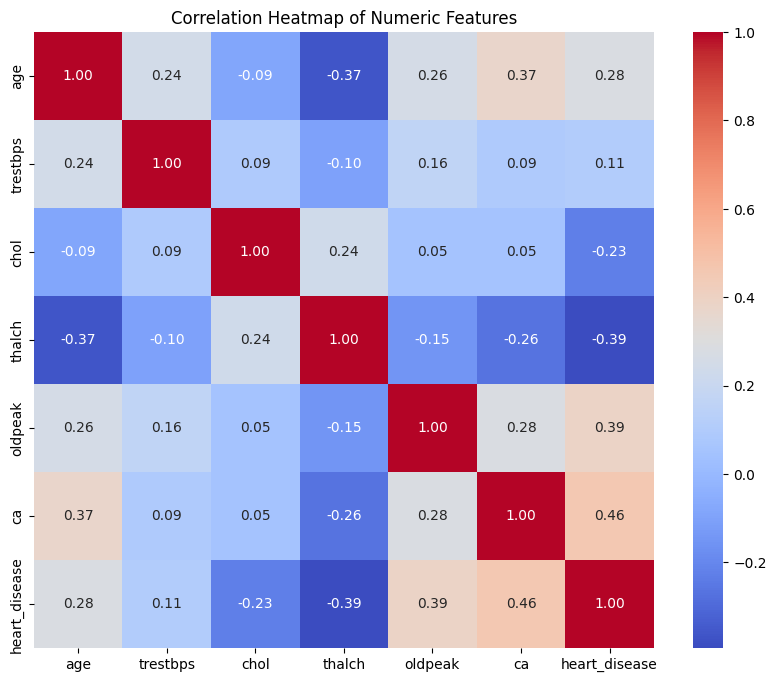

In [45]:
# EDA: correlation heatmap for numeric variables
numeric_cols_for_corr = df.select_dtypes(include=["int64", "float64"]).columns

numeric_cols_for_corr = numeric_cols_for_corr.drop(["id", "num"])

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numeric_cols_for_corr].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Observation**: The heatmap shows the correlation between numeric variables and the binary heart disease target. Among the numeric features, `ca` has the strongest positive correlation with heart disease, followed by `oldpeak` and `age`. The feature `thalch` has a negative correlation with heart disease, meaning that lower maximum heart rate values tend to be associated with heart disease in this dataset. Cholesterol has a weak negative correlation here, which is somewhat surprising and may reflect dataset-specific patterns or missing-value issues.

The original `num` column is highly correlated with `heart_disease` because `heart_disease` was created directly from `num`. Therefore, `num` should not be used as an input feature. The `id` column is also not meaningful for prediction and should be removed.

In [32]:
#  Decide features and target
X = df.drop(columns=["id", "num", "heart_disease"])
y = df["heart_disease"]

In [33]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')

Categorical features:
Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')


In [34]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
#  Build preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [36]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [37]:
# Build the full model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [38]:
#  Train the model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [39]:
# Make predictions
y_pred = model.predict(X_test)

In [40]:
#  Evaluate with accuracy, precision, recall, and F1
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.8370
Precision: 0.8273
Recall:    0.8922
F1 Score:  0.8585


In [41]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



**Observation**: The logistic regression model achieved an overall accuracy of 0.84 on the test set. For patients without heart disease, the model obtained a precision of 0.85, recall of 0.77, and F1-score of 0.81. For patients with heart disease, the model achieved a precision of 0.83, recall of 0.89, and F1-score of 0.86.

The recall for the heart disease class is particularly important because it measures how many actual heart disease cases the model successfully detected. A recall of 0.89 means the model identified most patients with heart disease, although it still missed some cases. Overall, the results suggest that logistic regression provides a reasonably strong baseline model for this dataset.

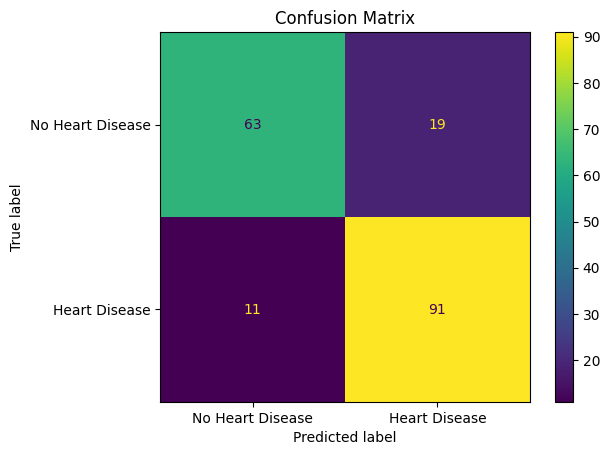

In [42]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Heart Disease", "Heart Disease"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

**Observation**: The confusion matrix shows that the model correctly classified 63 patients without heart disease and 91 patients with heart disease. It made 19 false positive predictions, where patients without heart disease were predicted to have heart disease, and 11 false negative predictions, where patients with heart disease were predicted not to have heart disease.

In this medical classification task, false negatives are especially important because they represent missed heart disease cases. The model produced 11 false negatives out of 102 actual heart disease cases, giving it a recall of approximately 0.89 for the heart disease class. This means the model successfully detected most patients with heart disease, although it did not catch all of them.

In [43]:
# Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]

y_proba[:10]

array([0.36523314, 0.97480682, 0.90556805, 0.96190095, 0.6104536 ,
       0.66197746, 0.35338641, 0.94093255, 0.12155096, 0.79611596])

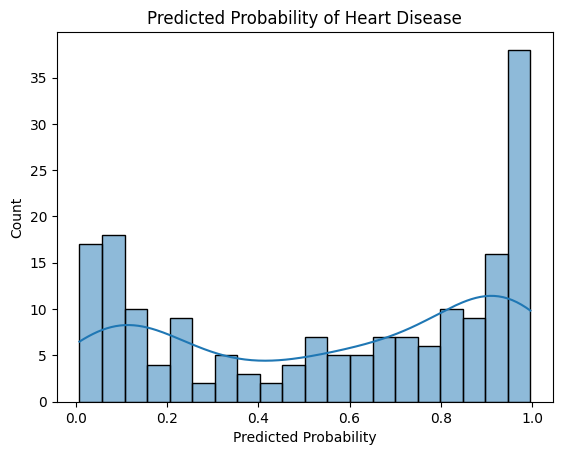

In [44]:
# Plot predicted probability distribution
sns.histplot(y_proba, bins=20, kde=True)
plt.title("Predicted Probability of Heart Disease")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

**Observation**: The predicted probability distribution shows that the logistic regression model often makes confident predictions. Many patients have predicted probabilities close to 0, meaning the model is confident they do not have heart disease, while many others have probabilities close to 1, meaning the model is confident they do have heart disease.

There are also some patients in the middle range, around 0.4 to 0.6. These are cases where the model is less certain. By default, logistic regression uses a threshold of 0.5: patients with predicted probability greater than or equal to 0.5 are classified as having heart disease, while patients below 0.5 are classified as not having heart disease.

Overall, this plot suggests that the model separates many patients reasonably well, but there are still borderline cases where prediction is more uncertain.